#Coustomer Support

In [ ]:
!pip install langchain langchain_core langchain_groq langgraph langchain_community --upgrade

In [ ]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display, Image
from langchain.chat_models import init_chat_model

In [ ]:
from google.colab import userdata
import os
os.environ['GROQ_API_KEY']=userdata.get('Groq_api')

In [ ]:
from langchain_groq import ChatGroq
llm = ChatGroq(temperature=0, model="llama-3.3-70b-versatile")

In [ ]:
llm.invoke("explain me about neural network?")

AIMessage(content='**Introduction to Neural Networks**\n=====================================\n\nA neural network is a machine learning model inspired by the structure and function of the human brain. It consists of layers of interconnected nodes or "neurons" that process and transmit information. Neural networks are designed to recognize patterns in data and learn from experience, making them a powerful tool for tasks such as image recognition, natural language processing, and decision-making.\n\n**Key Components of a Neural Network**\n--------------------------------------\n\n1. **Artificial Neurons (Nodes)**: These are the basic building blocks of a neural network. Each node receives one or more inputs, performs a computation on those inputs, and then sends the output to other nodes.\n2. **Connections (Edges)**: These are the links between nodes, which allow them to exchange information. Each connection has a weight associated with it, which determines the strength of the signal bei

In [ ]:
llm.invoke("what is langchain")

AIMessage(content='LangChain is an open-source framework designed to help developers build applications that utilize large language models (LLMs) more efficiently. It was created to simplify the process of integrating LLMs into various projects, making it easier for developers to leverage the capabilities of these powerful models.\n\nLangChain provides a set of tools and libraries that enable developers to:\n\n1. **Interact with LLMs**: LangChain offers a unified interface to interact with different LLMs, such as LLaMA, PaLM, and others, allowing developers to write code that works across multiple models.\n2. **Manage memory and caching**: LangChain includes features to manage memory and caching, which helps to reduce the computational resources required to run LLMs and improves overall performance.\n3. **Implement indexing and retrieval**: LangChain provides tools for indexing and retrieving information from LLMs, making it easier to build applications that require searching, filterin

In [ ]:
from typing import TypedDict, Dict
class State(TypedDict):
  query:str
  category:str
  sentiment:str
  response:str

In [ ]:
def categeorize(state:State) -> State:
  prompt = ChatPromptTemplate.from_template("Categorize the following query into one of the  following categories :Technical, Billing ,General . Query={query} ")
  chain = prompt | llm
  category = chain.invoke({"query": state["query"]}).content.strip().lower()
  print(f"categoory: {category}")
  return  {"category":category}


def analyze_sentiment(state:State) -> State:
  prompt = ChatPromptTemplate.from_template("Analyze the following query sentiment and ans in word and response with either 'positive', 'negative' or 'neutral'. Query={query} ")
  chain = prompt | llm
  sentiment = chain.invoke({"query": state["query"]}).content.strip().lower()
  print(f"sentiment : {sentiment}")
  return  {"sentiment":sentiment}

def handle_technical(state: State) -> State:

  print("handling the technical query")
  prompt = ChatPromptTemplate.from_template("provide the technical support response to the following query:{query}")
  chain = prompt | llm
  response = chain.invoke({"query": state["query"]}).content
  print(f"response: {response}")
  return  {"response":response}

def handle_billing(state:State) ->  State:
  print("handling the billing query")
  prompt = ChatPromptTemplate.from_template("provide the billing support response to the following query:{query}")
  chain = prompt | llm
  response = chain.invoke({"query": state["query"]}).content
  print(f"response: {response}")
  return  {"response":response}

def handle_general(state:State) -> State:
  print("handling the general query")
  prompt = ChatPromptTemplate.from_template("provide the general support response to the following query:{query}")
  chain = prompt | llm
  response = chain.invoke({"query": state["query"]}).content
  print(f"response: {response}")
  return  {"response":response}

def escalate(state: State)-> State:
  print("escalating the query")
  return{"response":"this query is been escalating to the the human agent because of its nagative sentiment"  }

def route_query(state: State) -> str:
    # Prioritize negative sentiment
    if state.get("sentiment") == "negative":
        return "escalate"

    # Route based on category
    return {
        "technical": "handle_technical",
        "billing": "handle_billing"
    }.get(state.get("category"), "handle_general")


In [ ]:
workflow = StateGraph(State)
workflow.add_node("categeorize",categeorize)
workflow.add_node("analyze_sentiment",analyze_sentiment)
workflow.add_node("handle_technical",handle_technical)
workflow.add_node("handle_billing",handle_billing)
workflow.add_node("handle_general",handle_general)
workflow.add_node("escalate",escalate)

workflow.add_conditional_edges("analyze_sentiment",route_query)


workflow.add_edge("categeorize","analyze_sentiment")
workflow.add_edge("handle_technical",END)
workflow.add_edge("handle_billing",END)
workflow.add_edge("handle_general",END)
workflow.add_edge("escalate",END)
workflow.set_entry_point("categeorize")
app = workflow.compile()

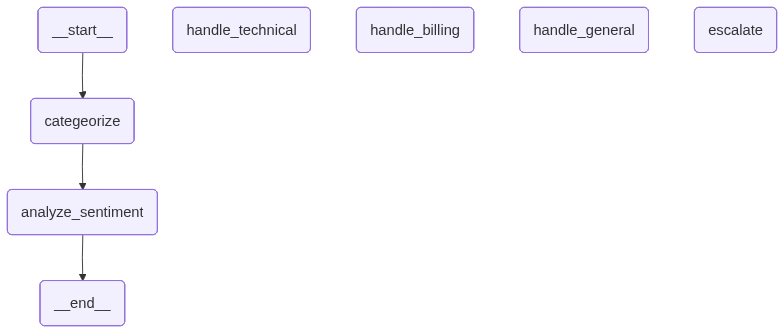

In [ ]:
from IPython.display import Image, display
try:
  display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
  print("mermaid not installed")

In [ ]:
def run_coustomer_support(query:str) -> Dict[str, str]:
  res = app.invoke({"query":query})
  return {
      "category":res["category"],
      "sentiment":res["sentiment"],
      "response":res["response"]
  }


In [ ]:
query ="when is the new lauch of iphone"
result = run_coustomer_support(query)
print(f"result of query {query}")
print(f"category: {result['category']}")
print(f"sentiment: {result['sentiment']}")
print(f"response: {result['response']}")

categoory: the query "when is the new launch of iphone" can be categorized as:

**general**

this is because the query is related to general information about a product (iphone) and its release date, rather than a technical issue or a billing inquiry.
sentiment : the sentiment of the query is: **positive** 

reason: the query is about a new launch of an iphone, which suggests excitement and interest, indicating a positive sentiment. the tone is also inquiring and anticipatory, which further supports a positive sentiment.
handling the general query
response: Thank you for reaching out to us. We're excited to hear that you're interested in the latest iPhone release.

Apple typically announces new iPhone models in the fall of each year, usually around September. However, the exact launch date has not been officially confirmed by Apple yet.

To stay up-to-date with the latest news and announcements, I recommend checking Apple's official website or following reputable tech news sources. You

In [ ]:
!pip install --pre -U langchain

In [ ]:
os.environ["LANGCHAIN_API_KEY"] = userdata.get('langchainKey')
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT"] = "GenAI"
os.environ["OPENAI_API_KEY"] = userdata.get('Groq_api')


#Chatbot

In [ ]:
from langgraph.graph import message
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages: Annotated[list, add_messages]


In [ ]:
graph_builder = StateGraph(State)

def chatbot(state: State):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

graph_builder.add_node("chatbot", chatbot)

graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

bot = graph_builder.compile()

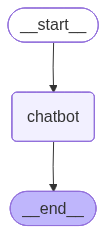

In [ ]:
from IPython.display import Image, display
try:
  display(Image(bot.get_graph().draw_mermaid_png()))
except Exception:
  print("mermaid not installed")

In [ ]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
bot = graph_builder.compile(checkpointer=memory)

In [ ]:
from langsmith import traceable
#not connected to the database currently using memory_Saver
@traceable
def stream_graph_updates(user_input: str):
    # Note: correct key is "messages"
    for event in bot.stream({"messages": [{"role": "user", "content": user_input}]},{"configurable":{"thread_id":"1"}}):
        for value in event.values():
            # value["messages"] is a list
            print("Assistant:", value["messages"][-1].content)

while True:
    try:
        user_input = input("User: ")

        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break

        stream_graph_updates(user_input)

    except:
        # fallback if input() not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

User: q
Goodbye!


#Enchancing the chat bot wiht the tool adding the tools for web Search Tool

In [ ]:
!pip install -U langchain-tavily langchain-anthropic

In [ ]:
import os

# Correct env variable name:
os.environ["TAVILY_API_KEY"] = userdata.get("Travley_Key")


In [ ]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)

result = tool.invoke("Tell me about deepsink llm launched in jan 2025")

result


{'query': 'Tell me about deepsink llm launched in jan 2025',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.techtarget.com/whatis/feature/DeepSeek-explained-Everything-you-need-to-know',
   'title': 'DeepSeek explained: Everything you need to know - TechTarget',
   'content': "## DeepSeek, a Chinese AI firm, is disrupting the industry with its low-cost, open source large language models, challenging U.S. tech giants. DeepSeek focuses on developing open source LLMs. The company's first model was released in November 2023. Since the company was created in 2023, DeepSeek has released a series of generative AI models. * **DeepSeek-R1.** Released in January 2025, this model is based on DeepSeek-V3 and is focused on advanced reasoning tasks directly competing with OpenAI's o1 model in performance, while maintaining a significantly lower cost structure. * **Business m****odel threat.** In contrast with OpenAI, which is proprietary technology, D

#With the tool Node

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict

from langchain_anthropic import ChatAnthropic
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import BaseMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)
tool = TavilySearchResults(max_results=2)
tools = [tool]

llm_with_tools = bot.bind(tools=tools)
def chatbot(state: State):
    return {
        "messages": [
            llm_with_tools.invoke(state["messages"])
        ]
    }

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")



In [ ]:
graph = graph_builder.compile(checkpointer=memory)

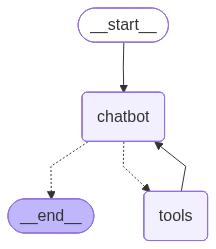

In [ ]:
from IPython.display import Image, display
try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
  print("mermaid not installed")

In [ ]:
from langsmith import traceable
#not connected to the database currently using memory_Saver
@traceable
def stream_graph_updates(user_input: str):
    # Note: correct key is "messages"
    for event in bot.stream({"messages": [{"role": "user", "content": user_input}]},{"configurable":{"thread_id":"4"}}):
        for value in event.values():
            # value["messages"] is a list
            print("Assistant:", value["messages"][-1].content)

while True:
    try:
        user_input = input("User: ")

        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break

        stream_graph_updates(user_input)

    except:
        # fallback if input() not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

User: hey
Assistant: Hello. How can I help you today?
User: tell abe about indian politics in 2025
Assistant: As of my knowledge cutoff in 2023, I can provide you with an overview of Indian politics up to that point. However, please note that my information may not reflect the current situation in 2025.

That being said, here's a brief overview of Indian politics as of 2023:

**Government:**
The Bharatiya Janata Party (BJP) led by Prime Minister Narendra Modi has been in power since 2014. The BJP has been the dominant party in Indian politics, with a strong presence in the Lok Sabha (the lower house of the Indian Parliament).

**Key Issues:**
Some of the key issues in Indian politics as of 2023 include:

1. **Economic Growth:** India has been one of the fastest-growing major economies in the world, with a focus on initiatives like "Make in India" and "Digital India" to boost economic growth.
2. **Farmers' Protests:** The Indian government has faced protests from farmers over issues lik